#ML FINAL EXAM

### Email: md.tuhin42525@gmail.com


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer:

<!-- Why you choose this dataset  -->
I chose the Bank Marketing Dataset because it is a real-world dataset that contains both numerical and categorical features. It is suitable for practicing data preprocessing, EDA, classification and unsupervised learning techniques.


<!-- what did you observe from the dataset description -->
The dataset contains customer demographic information and previous marketing campaign details. The goal is to predict whether a customer will subscibe to a term deposit. It includes different types of features and some missing values represented as "unknown".

# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import ConfusionMatrixDisplay, silhouette_score

from sklearn.metrics import accuracy_score, classification_report, precision_score, r2_score, recall_score, f1_score

##Answer:
1. Features have 17.
2. It's a Classification dataset. Because the target variable (deposit) has two classes: Yes and No. The objective is to predict which class a customer belongs to.
3. Data points : 45211
4. There is no null values. But this dataset have "unknown" i think this is null values, that's why i replace "unknown" to NaN.
5. Dataset have Bhot type of feature (Quantitative and Categorical)

Quantitative: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

6. Yes. Machine learning models cannot process text values directly. Therefore, categorical variables were encoded using OneHotEncoding in the preprocessing pipeline.

7. The correlation matrix showed that most numerical features  have weak correlations with each other. Highest positive correlation was observed between pdays and previous indicating a moderate relationship.

8. Some important observations from the EDA are:

Most customers did not subscribe to a term deposit.

Customers with a successful previous campaign (poutcome = success) were more likely to subscribe.

Most customers were married and had secondary education.

In [ ]:
df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
print("1. Features count: ", df.shape[1])
print("2. Problem type: Binary Classification (Predicting 'deposit' 1 or 0)", )
print("3. Data point: ", df.shape[0])
print("4. Null values: \n", df.isnull().sum())

quant = df.select_dtypes(include=[np.number]).columns.tolist()
cat = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"5. Quantitative: {quant}\n Categorical: {cat}")
display(df.head())

1. Features count:  17
2. Problem type: Binary Classification (Predicting 'deposit' 1 or 0)
3. Data point:  45211
4. Null values: 
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64
5. Quantitative: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
 Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


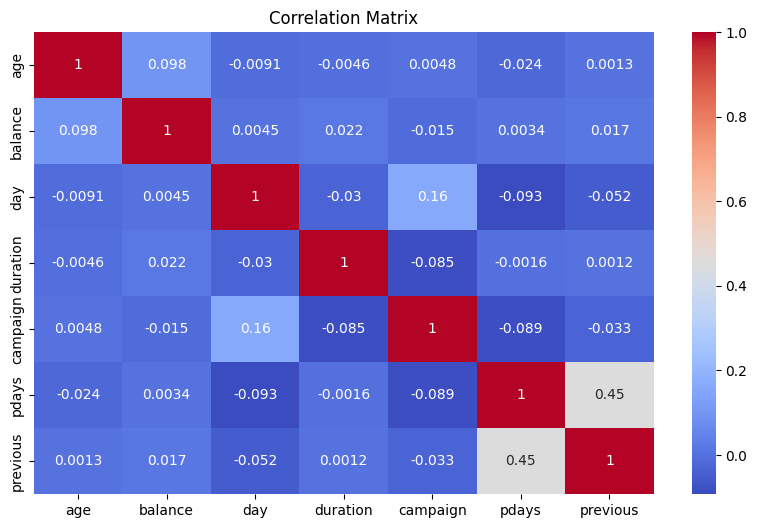

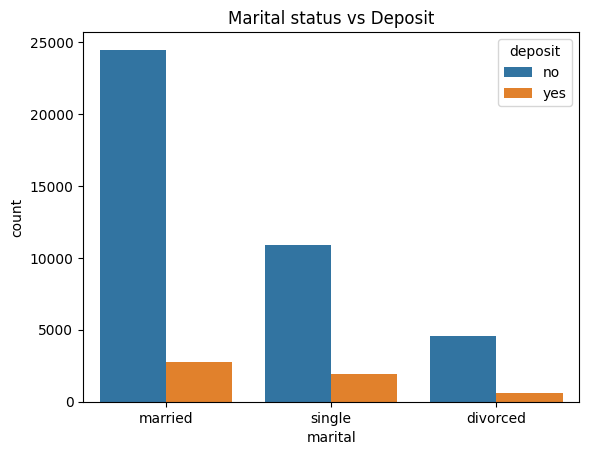

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# EDA Relationship
sns.countplot(x='marital', hue='deposit', data=df)
plt.title("Marital status vs Deposit")
plt.show()

#2. Dataset pre-processing (15 marks)

1. Provide code


2. Discuss the pre processing steps you applied and why?


## Answer:

1. replaced "unknown" values with NaN in the job, education and contact columns beacuse these values represent missing information rather than valid categories.
2. Checked for messing values using isnull().sum() to identify incomplete data.
3. Checked and removed duplicate records using duplicated() and drop_duplicates()
4. Handlesd missing values using SimpleImputer:

-> Median strategy for numerical features

-> Most frequent strategy for categorical features

5. Encoded categorical variables using OneHotEncoder because machine learning models cannot process categorical text values directly
6. Standardized numerical features using StandardScaler to bring all numerical variables to a similar scale.
7. Built a preprocessing pipeline using Pipeline and ColumnTransformer. This ensures that all preprocessing steps are applied consistently to both training and testing data while preventing data leakage.



These preprocessing steps were performed to improve data quality, handle missing information, convert categorical data into numerical form, scale numerical features and prepare the dtaset for machine learning models. Using a preprocessing pipeline also ensures a clean, resuable and reliable workflow while avoiding dta leakage during model training.

In [ ]:
cols = ['job', 'education', 'contact']
df[cols] = df[cols].replace('unknown', np.nan)
df.isnull().sum()


,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:

All input features were kept because each feature may contribute to predicting the target variable. Only the target column (deposit) was separated from the dataset

In [ ]:
X = df.drop('deposit', axis=1)
y = df['deposit']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_test = le.transform(y_test)

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

A pre processing pipeline was created to automate data preparation. The numerical pipeline handled missing values using SimpleImputer (median) and scaled the features using StandardScaler. The categorical pipeline handled missing values using SimpleImputer (most frequent) and encoded categorical features using OneHotEncoder. Finally, two supervised models --Logistic Regression and Random Forest Classifier -- were integrated with the preprocessing pipeline to ensure consistent pre processing and model training.

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [ ]:
num_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())
    ]
)

cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numumerical", num_pipe, num_cols),
        ("categorical", cat_pipe, cat_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('numumerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'balance', 'day', 'duration',
                                  'campaign', 'pdays', 'previous']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'poutcome'])])

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

The two supervised models, **Logistic Regression** and **Random Forest Classifier**, were trained using the preprocessed traing dataset through the pipeline. The models learned the relationship between the input features and the target variabl (deposit) and were then used to make predictions on the test dataset

In [ ]:
# LogisticRegression
lr_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000
        ))
    ]
)


lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, lr_pred))

Accuracy:  0.8376644918721663


In [ ]:
# RandomForestClassifier

RF_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100,
            # max_depth=5,
            random_state=42
        ))
    ]
)


RF_model.fit(X_train, y_train)
RF_pred = RF_model.predict(X_test)

print("Accuracy : ", accuracy_score(y_test, RF_pred))

Accuracy :  0.9042353201371226


#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

Random Forest achieved the highest accuracy (90.42%) and precision (66.49%), indicating better overall classification performance and fewer false positive predictions. However, Logistic Regression achieved a much higher recall (78.54%) and F1-score (53.10%), meaning it identified a larger proportion of actual positive cases. Therefore, if maximizing overall accuracy is the objective, Random Forest is the preferred model. If detecting as many positive deposit subscriptions as possible is more important, Logistic Regression would be a better choice.

In [ ]:
results = {
    "Model" : ["Logistic Regression", "Random Forest"],
    "Accuracy" : [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, RF_pred)
    ],
    "Precision" : [
        precision_score(y_test, lr_pred),
        precision_score(y_test, RF_pred)
    ],
    "Recall" : [
        recall_score(y_test, lr_pred),
        recall_score(y_test, RF_pred)
    ],
    "F1 Score" : [
        f1_score(y_test, lr_pred),
        f1_score(y_test, RF_pred)
    ]
}
comparison = pd.DataFrame(results)
comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.838,0.401,0.785,0.531
1,Random Forest,0.904,0.665,0.366,0.472


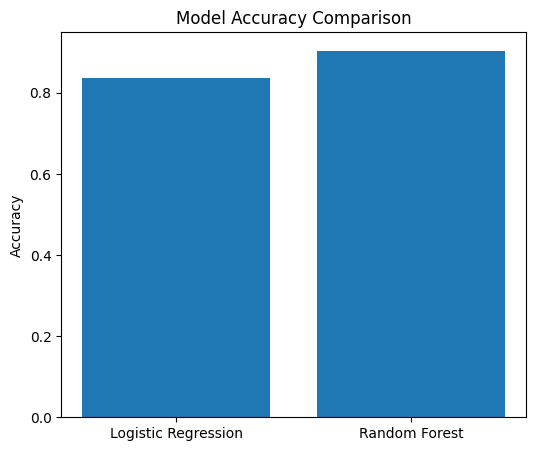

In [ ]:
plt.figure(figsize=(6, 5))
plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

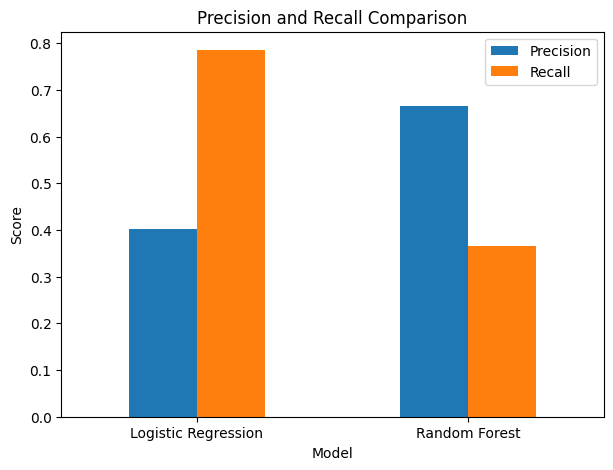

In [ ]:
comparison.set_index("Model")[["Precision", "Recall"]].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Precision and Recall Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Confusion Matrix

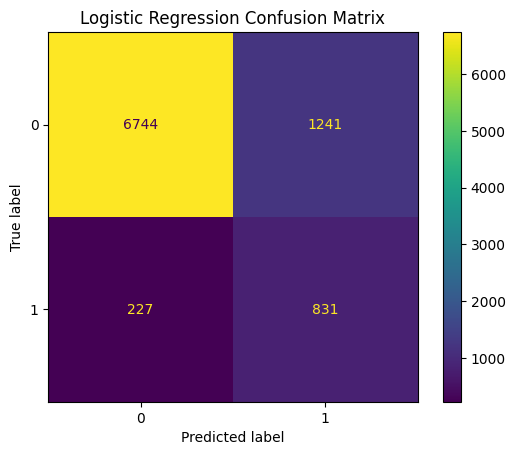

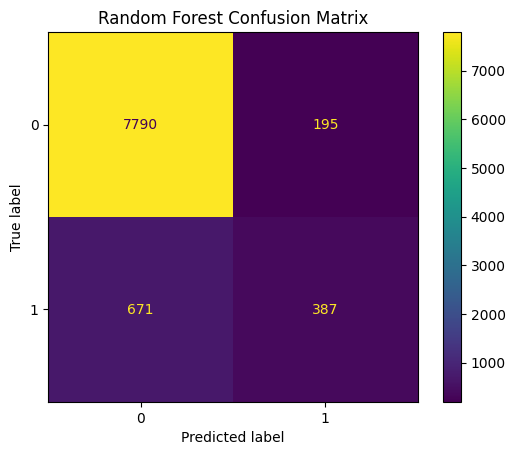

In [ ]:
# LogisticRegression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# RandomForestClassifier
ConfusionMatrixDisplay.from_predictions(
    y_test,
    RF_pred
)
plt.title("Random Forest Confusion Matrix")
plt.show()

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:
K-Means clustering produced a Silhouette Score of 0.226, indicating a fair but not strong clustering designed for supervised classification rather than clustering. The customer groups do not form highly distinct natural clusters, especially after encoding multiple categorical features. Therefore, the supervised models (Logistic Regression and Random Forest) achieved better performance than the unsupervised K-Means approach.

## Unsupervised = KMeans Model

In [ ]:
X_unsupervised = df.drop("deposit", axis=1)

In [ ]:
X_processed = preprocessor.fit_transform(X_unsupervised)

In [ ]:
# KMeans
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_processed)

In [ ]:
score = silhouette_score(X_processed, clusters)
print("Silhouette Score: ", score)

Silhouette Score:  0.2267999001572534


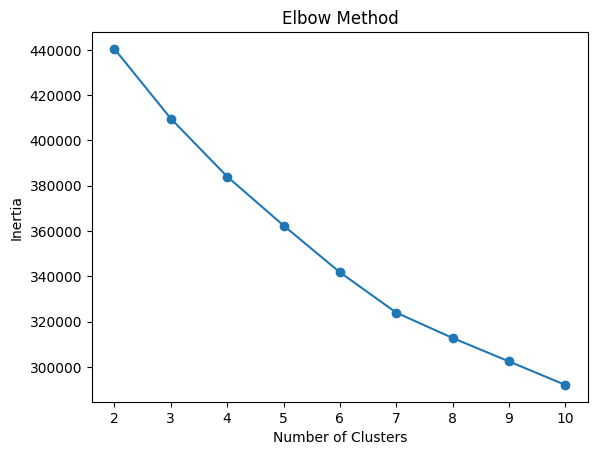

In [ ]:
inertia = []

for k in range(2, 11):
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(X_processed)
  inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

**Easiest Topic** : Decision Tree

Decision Tree was the easiest topic for me because its decision-making process is simple and easy to understand. It works like a flowchart by asking a series of questions. It is widely used in medical diagnosis, fraud detection and customer classification


**Hardest Topic:** Gradient Descent

Gradient Descent was the hardest topic for me because it involves mathematical concepts such as gradients, learning rate and  iterative optimization. However, it is and essential algorithm since it is used to train many machine learning and deep learning models